# Problema de las 8 reinas

### Juan Daniel Rangel Avila


este problema connsiste  en encontrar unn tablero de  ajedrez donde existan ocho reinas simultaneamennte sin que se ataquen entre  si nignuna de ellas.


las reinas se peuden atacar de las siguientes formas: unna reina ataca de dos  formas, en forma de "+" y forma de  "x"



para representar este problema se interpreta unn tablero de ajedrez como una matriz $ 8 $ x $ 8 $, las reinas se interpretan como dos  vectores $1$ x $8$

y las formas de atacar de las reinas se interpretan como las restricciones del problema.

se utilizara un algoritmo Recocido Simulado para resolver el prblema



##### import necesarios:

In [1]:
import random as r
import numpy as np

Funcion Objetivo:

se cuenta cuantas reinas estan en  conflicto, naturalmente se requiere minimizar esta funcion, siendo  el optimo global 0

In [2]:
def f(x,y,n:int):
    matriz=[(x[i],y[i]) for i in range(n)]
    cont=[]
    for i in range(n):
        a,b=x[i],y[i]  
        for j in range(1,n,1):
            jj,menosjj,jmenosj,menosjmenosj = (a+j,b+j), (a-j,b+j), (a+j,b-j), (a-j,b-j)
            if jj in matriz: 
                cont.append(jj)
            if menosjj in matriz:
                cont.append(menosjj)
            if jmenosj in matriz:
                cont.append(jmenosj)
            if menosjmenosj in matriz:
                cont.append(menosjmenosj)
    return len(set(cont))    

In [3]:
def get_initial_solution(n:int):
    x=r.sample(range(0,n), n)
    y=r.sample(range(0,n), n)
    return x,y

In [4]:
n=8
x,y=get_initial_solution(n)
print(f"x = {x}")
print(f"y = {y}")

x = [2, 1, 3, 7, 0, 6, 4, 5]
y = [1, 0, 5, 2, 4, 7, 6, 3]


In [5]:
f(x,y,n)

5

In [6]:
def get_neighbor(x, y, n:int):
    x_new = x[:]
    y_new = y[:]  
    if r.random() < 0.5:
        i, j = r.sample(range(n), 2)
        x_new[i], x_new[j] = x_new[j], x_new[i]
    else:
        i, j = r.sample(range(n), 2)
        y_new[i], y_new[j] = y_new[j], y_new[i]
    
    return x_new, y_new


In [7]:
get_neighbor(x, y, n)

([4, 1, 3, 7, 0, 6, 2, 5], [1, 0, 5, 2, 4, 7, 6, 3])

## Recocido  Simulado

In [8]:
def simulated_annealing(t_0, t_f, n:int):
    x = get_initial_solution(n)
    fx = f(*x, n)
    
    #print (f"Solucion inicial:\nx: {x[0]}\ny: {x[1]}\ncon f(x,y) = {fx}\n")
    
    xbest, fbest = x, fx

    t = t_0
    cont = 0
    while t > t_f:
        y = get_neighbor(*x, n)
        fy = f(*y, n)

        if fy <= fbest:
            xbest, fbest = y, fy
            if fbest == 0:
                break

        if fy <= fx or np.random.random() < np.exp( -(fy - fx)/t ):
            x, fx = y, fy
        cont += 1
        t *= 0.99
    #print(f"numero de iteraciones: {cont}\n")
    return xbest, fbest
    

In [9]:
import matplotlib.pyplot as plt

def dibujar_tablero(coordenadas, n:int):
    fig, ax = plt.subplots()

    # Dibujar cuadrícula blanca
    for x in range(n):
        for y in range(n):
            ax.add_patch(plt.Rectangle((x, y), 1, 1, fill=False, edgecolor="black"))

    # Dibujar las reinas como bolitas
    for (x, y) in coordenadas:
        ax.plot(x + 0.5, y + 0.5, "o", color="red", markersize=20)

    # Ajustes visuales
    ax.set_xlim(0, n)
    ax.set_ylim(0, n)
    ax.set_aspect("equal")
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.grid(False)
    plt.show()




Solucion final:
x: [69, 59, 22, 55, 96, 8, 14, 36, 30, 89, 77, 4, 5, 21, 39, 94, 61, 51, 62, 24, 33, 43, 63, 50, 90, 40, 71, 48, 54, 76, 44, 15, 1, 88, 41, 28, 65, 95, 2, 75, 31, 17, 91, 78, 97, 32, 9, 18, 81, 72, 37, 47, 73, 25, 19, 34, 85, 6, 80, 98, 13, 70, 52, 11, 53, 86, 79, 45, 84, 20, 10, 27, 82, 58, 0, 12, 46, 67, 56, 16, 42, 66, 23, 26, 68, 29, 60, 87, 83, 35, 64, 49, 74, 7, 99, 93, 92, 3, 38, 57]
y: [76, 51, 86, 74, 15, 5, 36, 84, 26, 23, 35, 62, 91, 67, 2, 45, 90, 21, 14, 56, 57, 95, 99, 54, 69, 13, 0, 44, 39, 88, 70, 30, 58, 42, 43, 63, 33, 12, 85, 93, 34, 31, 66, 55, 25, 71, 60, 7, 28, 65, 87, 11, 79, 81, 80, 10, 59, 16, 47, 92, 8, 53, 18, 64, 9, 46, 6, 19, 32, 61, 27, 98, 83, 3, 82, 77, 1, 89, 17, 78, 72, 48, 52, 68, 50, 97, 40, 49, 73, 22, 4, 94, 96, 20, 41, 24, 29, 37, 75, 38]
con f(x,y) = 19


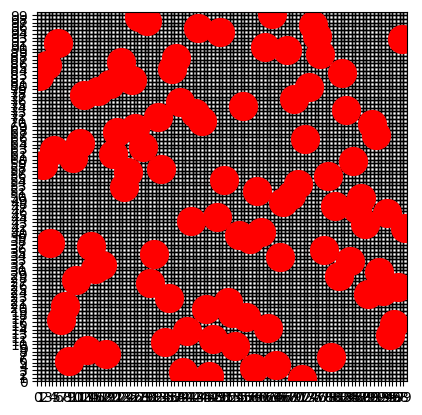

In [15]:
n=100
(x,y),result = simulated_annealing(10000, 0.001, n)
print(f"Solucion final:\nx: {x}\ny: {y}\ncon f(x,y) = {result}")
matriz=[(x[i],y[i]) for i in range(n)]
dibujar_tablero(matriz,n)

In [11]:
def m_runs(m,t,t_f,n:int):
    runs=[]
    for _ in range(m):
        runs.append(simulated_annealing(t, t_f, n))
    f_runs = [r[1] for r in runs]
    mean = np.mean(f_runs)
    std = np.std(f_runs)
    best = runs[np.argmin(f_runs)]
    worst = runs[np.argmax(f_runs)]
    runs.sort(key=lambda x: x[1])
    median = runs[m//2]
    return mean, std, best, worst, median

In [12]:
n=8
#cosas = m_runs(1000,10000, 0.001, n)
#print(f"Media: {cosas[0]}\nStd: {cosas[1]}\nMejor resultado: {cosas[2]}\nPeor resultado: {cosas[3]}\nMediana: {cosas[4]}")